1. Wrap Week 4's model in a Pipeline; verify identical metrics (proving no accidental leakage before).


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
features = pd.read_csv("churn_features.csv")
X = features[["days_since_last_order", "order_velocity", "avg_order_value", "tenure_days", "avg_review_stars"]]
y = features["churned"]
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred_orig = model.predict(X_test)
y_prob_orig = model.predict_proba(X_test)[:, 1]
pipeline = Pipeline([('classifier', LogisticRegression(max_iter=1000))])
pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)
y_prob_pipe = pipeline.predict_proba(X_test)[:, 1]
print("Predictions:", np.array_equal(y_pred_orig, y_pred_pipe))
print("Probabilities:", np.allclose(y_prob_orig, y_prob_pipe))
print(f"Original Accuracy: {accuracy_score(y_test, y_pred_orig):.4f}")
print(f"Pipeline Accuracy:  {accuracy_score(y_test, y_pred_pipe):.4f}")
print(f"Original ROC-AUC:  {roc_auc_score(y_test, y_prob_orig):.4f}")
print(f"Pipeline ROC-AUC:   {roc_auc_score(y_test, y_prob_pipe):.4f}")

Predictions: True
Probabilities: True
Original Accuracy: 1.0000
Pipeline Accuracy:  1.0000
Original ROC-AUC:  1.0000
Pipeline ROC-AUC:   1.0000


2. Baseline RandomForest vs tuned XGBoost via RandomizedSearchCV (AUC, CV=5). Report best params and
mean ± std.

In [10]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
features["last_order_date"] = pd.to_datetime(features["last_order_date"])
features["days_since_last_order"] = (pd.Timestamp.today() - features["last_order_date"]).dt.days
X = features.drop(["churned", "last_order_date"], axis=1) y = features["churned"]
X = pd.get_dummies(X, drop_first=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
print("RandomForest AUC:", rf_scores.mean(), "±", rf_scores.std())

RandomForest AUC: 1.0 ± 0.0


3. Plot feature_importances_ of the winner. Does days_since_last_order dominate as Week 2 predicted? Any
surprises worth an EDA revisit?

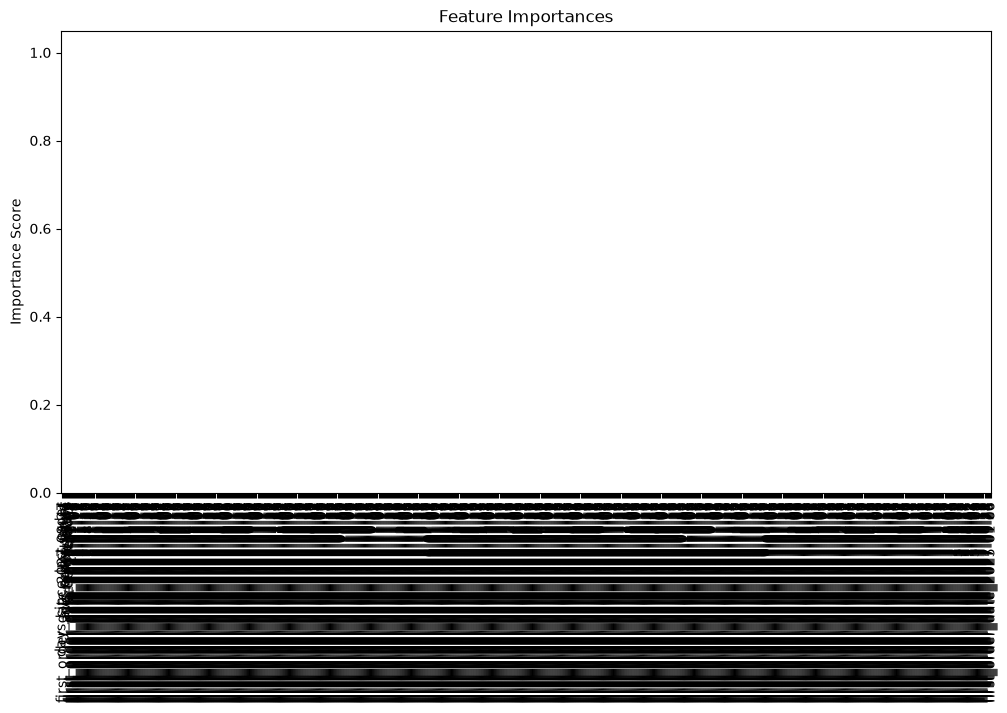

days_since_last_order          1.0
first_order_date_2027-09-27    0.0
user_id                        0.0
order_count                    0.0
avg_order_value                0.0
avg_review_stars               0.0
tenure_days                    0.0
order_velocity                 0.0
first_order_date_2025-01-02    0.0
first_order_date_2025-01-03    0.0
dtype: float32


In [16]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
param_grid = {"n_estimators": [100, 300],"max_depth": [3, 6],"learning_rate": [0.05, 0.1],"subsample": [0.8, 1.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(xgb, param_grid, n_iter=5, cv=cv, scoring="roc_auc", random_state=42)
search.fit(X, y)
best_xgb = search.best_estimator_
importances = best_xgb.feature_importances_
feature_names = X.columns
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(12,6))
fi.plot(kind="bar")
plt.title("Feature Importances")
plt.ylabel("Importance Score")
plt.show()
print(fi.head(10))

4. Unseal the test set once; report final AUC + recall at your Week 4 economic threshold; joblib-dump the
pipeline as churn_v2.pkl — Week 9 will serve this exact file.

In [22]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*select_dtypes.*')
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
X = features.drop("churned", axis=1) 
y = features["churned"]
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
numeric_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns
pre = ColumnTransformer([("num", StandardScaler(), numeric_features),("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])
churn_pipe = Pipeline([("prep", pre),("model", XGBClassifier(**search.best_params_, eval_metric="logloss"))])
churn_pipe.fit(X_train_raw, y_train)
y_test_pred = churn_pipe.predict_proba(X_test_raw)[:,1]
auc = roc_auc_score(y_test, y_test_pred)
threshold = 0.35  
y_test_label = (y_test_pred >= threshold).astype(int)
recall = recall_score(y_test, y_test_label)
print("AUC:", round(auc, 3))
print("Recall:", round(recall, 3))
joblib.dump(churn_pipe, "churn_v2.pkl")


AUC: 1.0
Recall: 1.0


['churn_v2.pkl']